In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.DataFrame(columns=['x', 'y'])

In [ ]:
# .loc[0] index(행 번호)가 0인 위치를 가리키는 이름표로서, 그 자리에 3과 1을 넣으라는 의미
df.loc[0] = [3,1]
df.loc[1] = [10,5]
df.loc[2] = [15,2]

In [5]:
df.head(3)

,x,y
0,3,1
1,10,5
2,15,2


Text(29.000000000000007, 0.5, 'y')

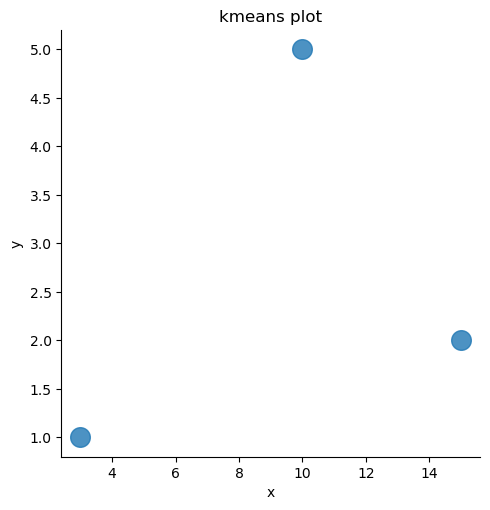

In [10]:
# Linear Model Plot(lmplot) 데이터 사이의 상관관계를 시각화하는 도구
# shift + tap = 함수의 내부 구성(파라미터, 설명)을 확인할 수 있는 단축키
sns.lmplot(x='x', y='y', data=df, fit_reg=False, scatter_kws={"s": 200})
plt.title('kmeans plot')
plt.xlabel('x')
plt.ylabel('y')

In [15]:
# 데이터 프레임의 값들을 numpy의 array 형태로 변환한다.
data_points = df.values

In [13]:
kmeans = KMeans(n_clusters=3).fit(data_points)

C:\Users\1724q\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [14]:
kmeans.labels_

array([0, 2, 1], dtype=int32)

In [16]:
kmeans.cluster_centers_

array([[ 3.,  1.],
       [15.,  2.],
       [10.,  5.]])

In [18]:
df['cluster_id'] = kmeans.labels_

In [20]:
df.head()

,x,y,cluster_id
0,3,1,0
1,10,5,2
2,15,2,1


Text(0.5, 1.0, 'After kmean clustering')

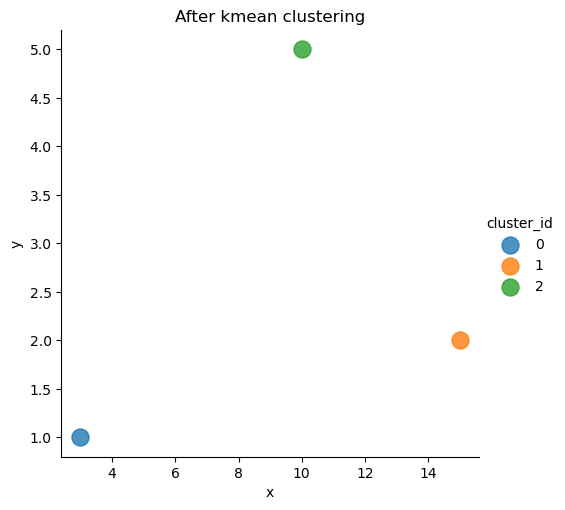

In [24]:
# hue: 데이터의 색상 그룹화. 지정한 열 값에 따라 다른 색으로 표시한다.
# scatter_kws(Keyword Arguments): 산점도에 찍히는 점들의 겉모양을 설정하는 딕셔너리.
# 즉, s=200은 size를 200으로 키우라는 의미다. alpha = 0.5는 투명하게 만드는 것.
# Fit regression = fit_reg: 데이터의 추세를 나타내는 직선 유무
sns.lmplot(x='x', y='y', hue='cluster_id', fit_reg=False, data=df, scatter_kws={"s": 150})
plt.title('After kmean clustering')